In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
#1 Load and Explore Dataset
# Load the dataset.
# Display first rows.
# Shape.
# Data types.
# Missing values.
# Duplicate rows.
# Summary statistics.

In [6]:
df = pd.read_csv("vgsales.csv")

In [7]:
df.head(10)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


In [8]:
df.shape

(16598, 11)

In [9]:
df.dtypes

Rank              int64
Name             object
Platform         object
Year            float64
Genre            object
Publisher        object
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

In [10]:
df.isnull().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [11]:
df.describe(include="all")

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16598,16598,16327.000000,16598,16540,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
unique,NaN,11493,31,NaN,12,578,NaN,NaN,NaN,NaN,NaN
top,NaN,Need for Speed: Most Wanted,DS,NaN,Action,Electronic Arts,NaN,NaN,NaN,NaN,NaN
freq,NaN,12,2163,NaN,3316,1351,NaN,NaN,NaN,NaN,NaN
mean,8300.605254,NaN,NaN,2006.406443,NaN,NaN,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,NaN,NaN,5.828981,NaN,NaN,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,NaN,NaN,1980.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,NaN,NaN,2003.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,NaN,NaN,2007.000000,NaN,NaN,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,NaN,NaN,2010.000000,NaN,NaN,0.240000,0.110000,0.040000,0.040000,0.470000


In [12]:
#2 Data Cleaning
# Remove duplicates.
# Handle missing values.
# Convert purchase and sold dates into datetime.
# Verify cleaned data.

In [13]:
df["Year"] = df["Year"].fillna(df["Year"].median())

In [15]:
df["Publisher"] = df["Publisher"].fillna("Unknown")

In [17]:
df["Year"] = df["Year"].astype(int)

In [19]:
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())

print("\nFirst Five Rows")
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16598 non-null  int64  
 4   Genre         16598 non-null  object 
 5   Publisher     16598 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 1.4+ MB
None

Missing Values
Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

Duplicate Rows
0

First Five Rows
   

In [27]:
#3 Platform Analysis
# Count games by platform.
# Total global sales by platform.
# Top 10 platforms.

In [22]:
df["Platform"].value_counts()

Platform
DS      2163
PS2     2161
PS3     1329
Wii     1325
X360    1265
PSP     1213
PS      1196
PC       960
XB       824
GBA      822
GC       556
3DS      509
PSV      413
PS4      336
N64      319
SNES     239
XOne     213
SAT      173
WiiU     143
2600     133
NES       98
GB        98
DC        52
GEN       27
NG        12
SCD        6
WS         6
3DO        3
TG16       2
GG         1
PCFX       1
Name: count, dtype: int64

In [24]:
platform_sales = df.groupby("Platform")["Global_Sales"].sum()

print(platform_sales)

Platform
2600      97.08
3DO        0.10
3DS      247.46
DC        15.97
DS       822.49
GB       255.45
GBA      318.50
GC       199.36
GEN       28.36
GG         0.04
N64      218.88
NES      251.07
NG         1.44
PC       258.82
PCFX       0.03
PS       730.66
PS2     1255.64
PS3      957.84
PS4      278.10
PSP      296.28
PSV       61.93
SAT       33.59
SCD        1.87
SNES     200.05
TG16       0.16
WS         1.42
Wii      926.71
WiiU      81.86
X360     979.96
XB       258.26
XOne     141.06
Name: Global_Sales, dtype: float64


In [26]:
top_10_platforms = df.groupby("Platform")["Global_Sales"].sum().sort_values(ascending=False).head(10)

print(top_10_platforms)

Platform
PS2     1255.64
X360     979.96
PS3      957.84
Wii      926.71
DS       822.49
PS       730.66
GBA      318.50
PSP      296.28
PS4      278.10
PC       258.82
Name: Global_Sales, dtype: float64


In [28]:
#4 Genre Analysis
# Number of games by genre.
# Total sales by genre.
# Average sales by genre.

In [30]:
df["Genre"].value_counts()

Genre
Action          3316
Sports          2346
Misc            1739
Role-Playing    1488
Shooter         1310
Adventure       1286
Racing          1249
Platform         886
Simulation       867
Fighting         848
Strategy         681
Puzzle           582
Name: count, dtype: int64

In [32]:
genre_sales = df.groupby("Genre")["Global_Sales"].sum()

print(genre_sales)

Genre
Action          1751.18
Adventure        239.04
Fighting         448.91
Misc             809.96
Platform         831.37
Puzzle           244.95
Racing           732.04
Role-Playing     927.37
Shooter         1037.37
Simulation       392.20
Sports          1330.93
Strategy         175.12
Name: Global_Sales, dtype: float64


In [34]:
genre_average_sales = df.groupby("Genre")["Global_Sales"].mean()

print(genre_average_sales)

Genre
Action          0.528100
Adventure       0.185879
Fighting        0.529375
Misc            0.465762
Platform        0.938341
Puzzle          0.420876
Racing          0.586101
Role-Playing    0.623233
Shooter         0.791885
Simulation      0.452364
Sports          0.567319
Strategy        0.257151
Name: Global_Sales, dtype: float64


In [35]:
#5 Publisher Analysis
# Top 10 publishers.
# Total sales by publisher.
# Average sales by publisher.

In [37]:
top_10_publishers = df["Publisher"].value_counts().head(10)

print(top_10_publishers)

Publisher
Electronic Arts                 1351
Activision                       975
Namco Bandai Games               932
Ubisoft                          921
Konami Digital Entertainment     832
THQ                              715
Nintendo                         703
Sony Computer Entertainment      683
Sega                             639
Take-Two Interactive             413
Name: count, dtype: int64


In [39]:
publisher_sales = df.groupby("Publisher")["Global_Sales"].sum()

print(publisher_sales)

Publisher
10TACLE Studios                  0.11
1C Company                       0.10
20th Century Fox Video Games     1.94
2D Boy                           0.04
3DO                             10.12
                                ...  
id Software                      0.03
imageepoch Inc.                  0.04
inXile Entertainment             0.10
mixi, Inc                        0.86
responDESIGN                     0.13
Name: Global_Sales, Length: 578, dtype: float64


In [41]:
publisher_average_sales = df.groupby("Publisher")["Global_Sales"].mean()

print(publisher_average_sales)

Publisher
10TACLE Studios                 0.036667
1C Company                      0.033333
20th Century Fox Video Games    0.388000
2D Boy                          0.040000
3DO                             0.281111
                                  ...   
id Software                     0.030000
imageepoch Inc.                 0.020000
inXile Entertainment            0.100000
mixi, Inc                       0.860000
responDESIGN                    0.065000
Name: Global_Sales, Length: 578, dtype: float64


In [42]:
#6 Regional Sales Analysis

# Calculate total sales in:

# North America
# Europe
# Japan
# Other regions
# Compare regional sales.

In [44]:
regional_sales = {
    "North America": df["NA_Sales"].sum(),
    "Europe": df["EU_Sales"].sum(),
    "Japan": df["JP_Sales"].sum(),
    "Other Regions": df["Other_Sales"].sum()
}

print(pd.Series(regional_sales))

North America    4392.95
Europe           2434.13
Japan            1291.02
Other Regions     797.75
dtype: float64


In [45]:
# #7 Global Sales Analysis
# Highest selling game.
# Lowest selling game.
# Average global sales.
# Top 20 games.

In [47]:
df["Global_Sales"].min()

0.01

In [49]:
lowest_sales = df["Global_Sales"].min()

print(df[df["Global_Sales"] == lowest_sales])

        Rank                                               Name Platform  \
15980  15983                                              Turok       PC   
15981  15984                     Coven and Labyrinth of Refrain      PSV   
15982  15985  Super Battle For Money Sentouchuu: Kyuukyoku n...      3DS   
15983  15986                                   Dragon Zakura DS       DS   
15984  15987                             Chameleon: To Dye For!       DS   
...      ...                                                ...      ...   
16593  16596                 Woody Woodpecker in Crazy Castle 5      GBA   
16594  16597                      Men in Black II: Alien Escape       GC   
16595  16598   SCORE International Baja 1000: The Official Game      PS2   
16596  16599                                         Know How 2       DS   
16597  16600                                   Spirits & Spells      GBA   

       Year     Genre             Publisher  NA_Sales  EU_Sales  JP_Sales  \
15980  200

In [51]:
df["Global_Sales"].mean()

np.float64(0.5374406555006629)

In [53]:
top_20_games = df.sort_values(
    by="Global_Sales",
    ascending=False
).head(20)

print(top_20_games)

    Rank                                          Name Platform  Year  \
0      1                                    Wii Sports      Wii  2006   
1      2                             Super Mario Bros.      NES  1985   
2      3                                Mario Kart Wii      Wii  2008   
3      4                             Wii Sports Resort      Wii  2009   
4      5                      Pokemon Red/Pokemon Blue       GB  1996   
5      6                                        Tetris       GB  1989   
6      7                         New Super Mario Bros.       DS  2006   
7      8                                      Wii Play      Wii  2006   
8      9                     New Super Mario Bros. Wii      Wii  2009   
9     10                                     Duck Hunt      NES  1984   
10    11                                    Nintendogs       DS  2005   
11    12                                 Mario Kart DS       DS  2005   
12    13                   Pokemon Gold/Pokemon Sil

In [54]:
#8 Year-wise Analysis
# Games released each year.
# Total yearly sales.
# Best selling year.
# Worst selling year.

In [55]:
games_per_year = df["Year"].value_counts().sort_index()

print(games_per_year)

Year
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      60
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     349
2001     482
2002     829
2003     775
2004     763
2005     941
2006    1008
2007    1473
2008    1428
2009    1431
2010    1259
2011    1139
2012     657
2013     546
2014     582
2015     614
2016     344
2017       3
2020       1
Name: count, dtype: int64


In [57]:
yearly_sales = df.groupby("Year")["Global_Sales"].sum()

print(yearly_sales)

Year
1980     11.38
1981     35.77
1982     28.86
1983     16.79
1984     50.36
1985     53.94
1986     37.07
1987     21.74
1988     47.22
1989     73.45
1990     49.39
1991     32.23
1992     76.16
1993     45.98
1994     79.17
1995     88.11
1996    199.15
1997    200.98
1998    256.47
1999    251.27
2000    201.56
2001    331.47
2002    395.52
2003    357.85
2004    419.31
2005    459.94
2006    521.04
2007    711.21
2008    678.90
2009    667.30
2010    600.45
2011    515.99
2012    363.54
2013    368.11
2014    337.05
2015    264.44
2016     70.93
2017      0.05
2020      0.29
Name: Global_Sales, dtype: float64


In [59]:
yearly_sales = df.groupby("Year")["Global_Sales"].sum()

print("Best Selling Year:", yearly_sales.idxmax())
print("Total Sales:", yearly_sales.max())

Best Selling Year: 2007
Total Sales: 711.21


In [61]:
yearly_sales = df.groupby("Year")["Global_Sales"].sum()

print("Worst Selling Year:", yearly_sales.idxmin())
print("Total Sales:", yearly_sales.min())

Worst Selling Year: 2017
Total Sales: 0.05


In [62]:
#9 NumPy Analysis

# Calculate:

# Mean global sales
# Median global sales
# Standard deviation
# Percentiles

In [64]:
np.mean(df["Global_Sales"])

np.float64(0.5374406555006629)

In [66]:
np.median(df["Global_Sales"])

np.float64(0.17)

In [68]:
np.std(df["Global_Sales"])

1.5549810910296504

In [70]:
percentiles = np.percentile(df["Global_Sales"], [25, 50, 75])

print(percentiles)

[0.06 0.17 0.47]


In [71]:
#10 Visualization

# Create:

# Genre bar chart
# Platform bar chart
# Global sales histogram
# Boxplot of sales
# Line chart of yearly sales
# Scatterplot Global Sales vs NA Sales
# Scatterplot Global Sales vs EU Sales
# Correlation heatmap

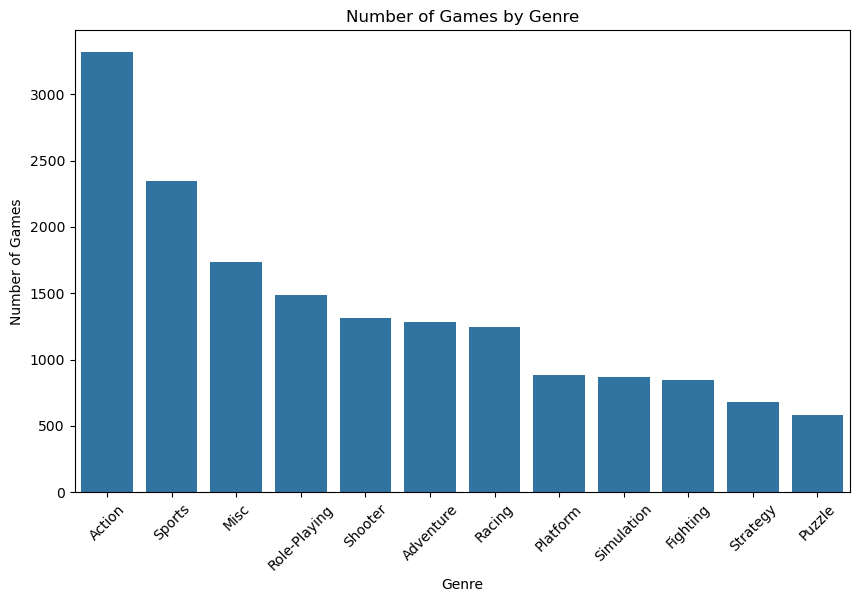

In [73]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="Genre",
    order=df["Genre"].value_counts().index
)

plt.title("Number of Games by Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Games")
plt.xticks(rotation=45)

plt.show()

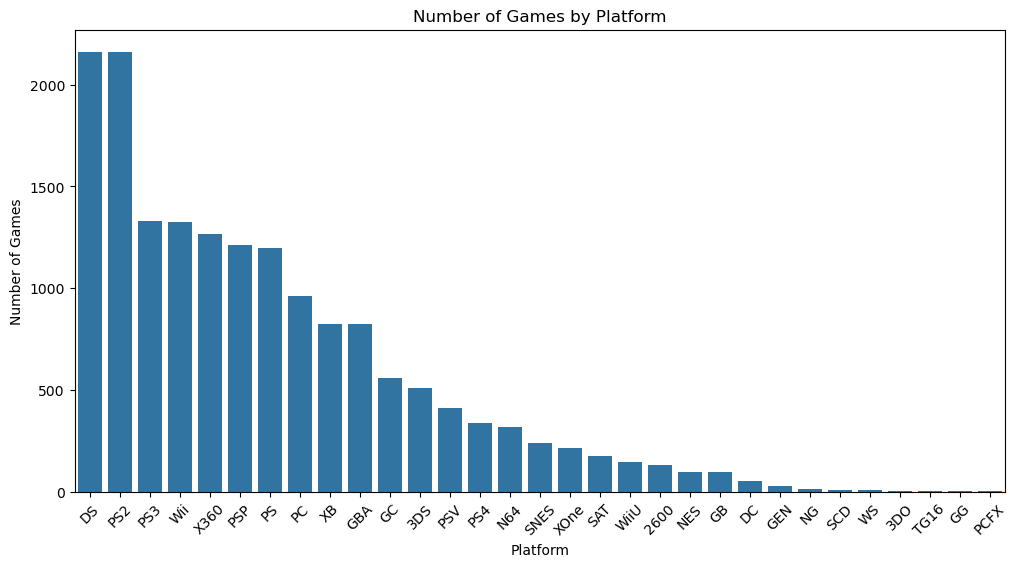

In [75]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="Platform",
    order=df["Platform"].value_counts().index
)

plt.title("Number of Games by Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Games")
plt.xticks(rotation=45)

plt.show()

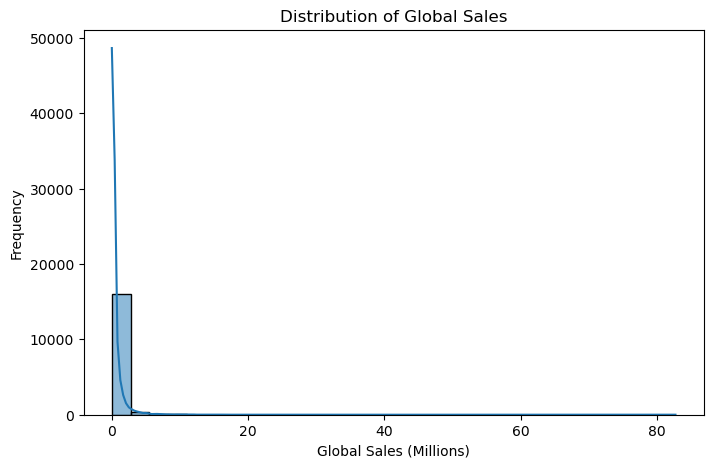

In [77]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Global_Sales",
    bins=30,
    kde=True
)

plt.title("Distribution of Global Sales")
plt.xlabel("Global Sales (Millions)")
plt.ylabel("Frequency")

plt.show()

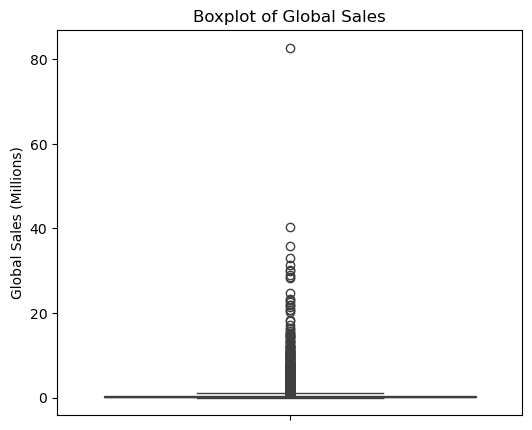

In [79]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    y="Global_Sales"
)

plt.title("Boxplot of Global Sales")
plt.ylabel("Global Sales (Millions)")

plt.show()

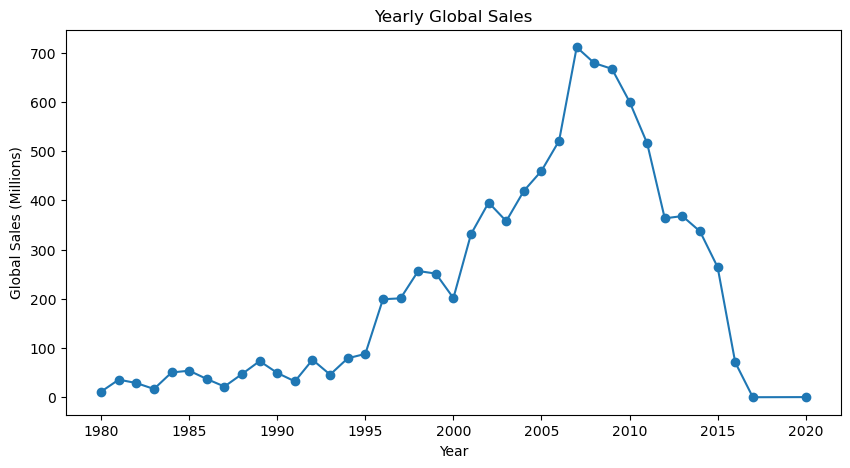

In [81]:
yearly_sales = df.groupby("Year")["Global_Sales"].sum()

plt.figure(figsize=(10,5))

plt.plot(
    yearly_sales.index,
    yearly_sales.values,
    marker="o"
)

plt.title("Yearly Global Sales")
plt.xlabel("Year")
plt.ylabel("Global Sales (Millions)")

plt.show()

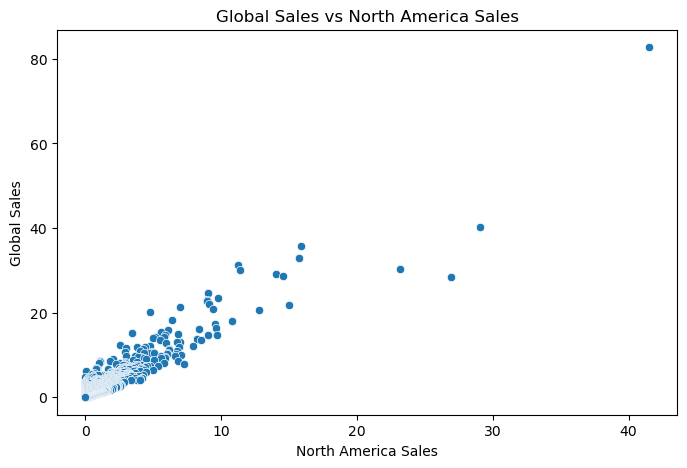

In [83]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="NA_Sales",
    y="Global_Sales"
)

plt.title("Global Sales vs North America Sales")
plt.xlabel("North America Sales")
plt.ylabel("Global Sales")

plt.show()

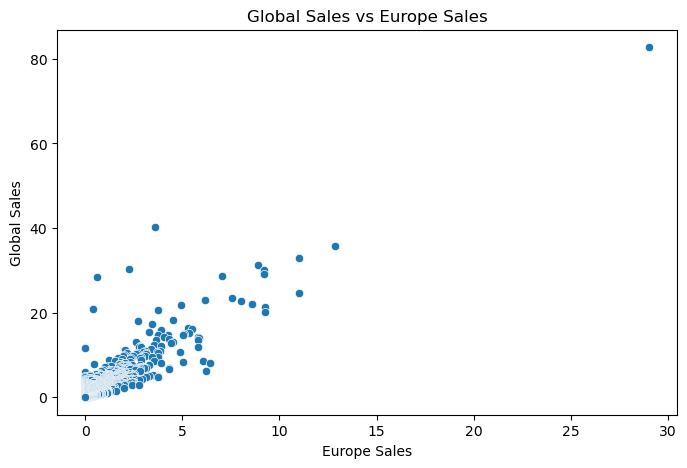

In [85]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="EU_Sales",
    y="Global_Sales"
)

plt.title("Global Sales vs Europe Sales")
plt.xlabel("Europe Sales")
plt.ylabel("Global Sales")

plt.show()

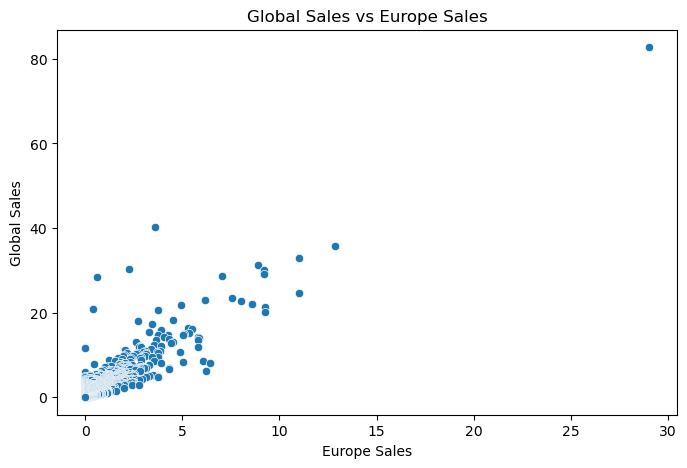

In [87]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="EU_Sales",
    y="Global_Sales"
)

plt.title("Global Sales vs Europe Sales")
plt.xlabel("Europe Sales")
plt.ylabel("Global Sales")

plt.show()

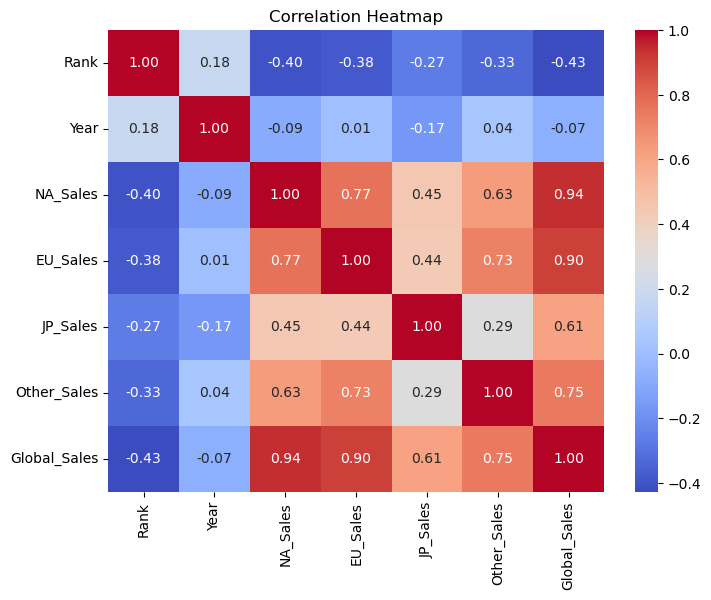

In [89]:
plt.figure(figsize=(8,6))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

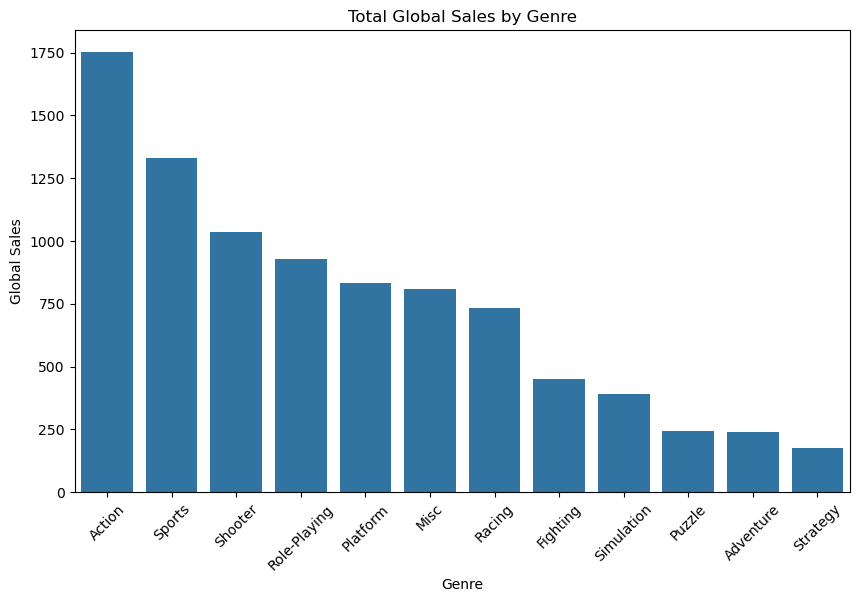

In [91]:
plt.figure(figsize=(10,6))

genre_sales = (
    df.groupby("Genre")["Global_Sales"]
      .sum()
      .sort_values(ascending=False)
)

sns.barplot(
    x=genre_sales.index,
    y=genre_sales.values
)

plt.title("Total Global Sales by Genre")
plt.xlabel("Genre")
plt.ylabel("Global Sales")
plt.xticks(rotation=45)

plt.show()

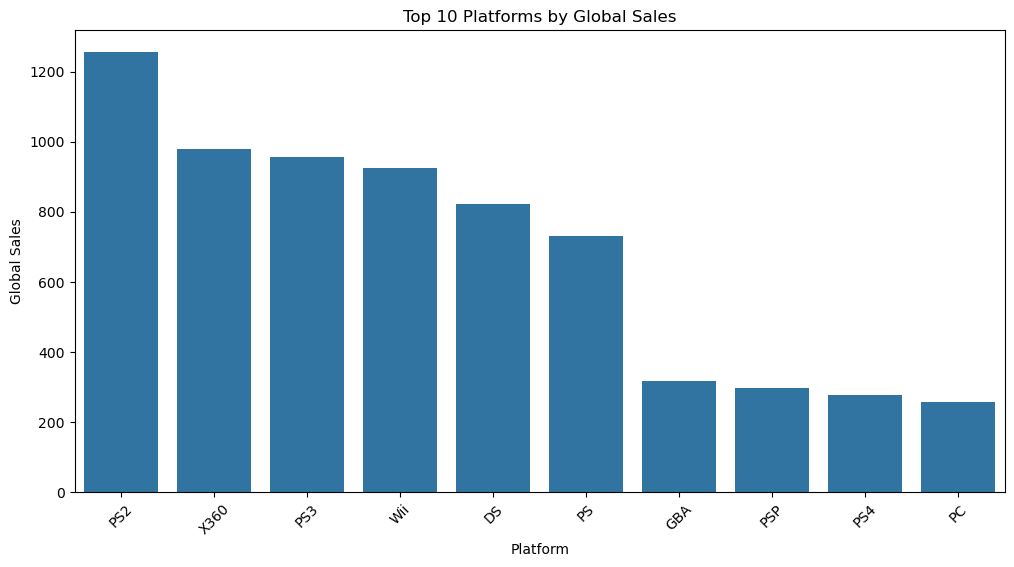

In [93]:
plt.figure(figsize=(12,6))

platform_sales = (
    df.groupby("Platform")["Global_Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

sns.barplot(
    x=platform_sales.index,
    y=platform_sales.values
)

plt.title("Top 10 Platforms by Global Sales")
plt.xlabel("Platform")
plt.ylabel("Global Sales")
plt.xticks(rotation=45)

plt.show()

In [94]:
# #11 Advanced Pandas
# Create a pivot table:
# Rows = Platform
# Columns = Genre
# Values = Average Global Sales
# Create another pivot table:
# Rows = Year
# Columns = Platform
# Values = Total Global Sales

In [96]:
pivot1 = pd.pivot_table(
    df,
    index="Platform",
    columns="Genre",
    values="Global_Sales",
    aggfunc="mean"
)

print(pivot1)

Genre       Action  Adventure  Fighting      Misc  Platform    Puzzle  \
Platform                                                                
2600      0.480984   0.850000  0.620000  0.716000  1.474444  1.334545   
3DO            NaN   0.060000       NaN       NaN       NaN  0.020000   
3DS       0.313297   0.130000  0.747143  0.197736  1.151071  0.278500   
DC        0.420000   0.227273  0.152500       NaN  1.270000       NaN   
DS        0.336910   0.197042  0.200000  0.350534  0.841848  0.354160   
GB        1.320000   3.432000       NaN  1.668750  2.890000  3.164667   
GBA       0.333892   0.386316  0.183043  0.329545  0.551408  0.315122   
GC        0.374653   0.296500  0.438810  0.464722  0.392603  0.361538   
GEN       0.913333   0.095000  1.180000  0.030000  2.207143       NaN   
GG             NaN        NaN       NaN       NaN  0.040000       NaN   
N64       0.778421   0.112500  0.761379  0.621667  1.204333  0.284167   
NES       2.211538   4.380000  1.635000  1.795000  

In [98]:
pivot2 = pd.pivot_table(
    df,
    index="Year",
    columns="Platform",
    values="Global_Sales",
    aggfunc="sum"
)

print(pivot2)

Platform   2600   3DO    3DS    DC      DS     GB    GBA     GC    GEN    GG  \
Year                                                                           
1980      11.38   NaN    NaN   NaN     NaN    NaN    NaN    NaN    NaN   NaN   
1981      35.77   NaN    NaN   NaN     NaN    NaN    NaN    NaN    NaN   NaN   
1982      28.86   NaN    NaN   NaN     NaN    NaN    NaN    NaN    NaN   NaN   
1983       5.83   NaN    NaN   NaN     NaN    NaN    NaN    NaN    NaN   NaN   
1984       0.27   NaN    NaN   NaN     NaN    NaN    NaN    NaN    NaN   NaN   
1985       0.45   NaN    NaN   NaN    0.02    NaN    NaN    NaN    NaN   NaN   
1986       0.66   NaN    NaN   NaN     NaN    NaN    NaN    NaN    NaN   NaN   
1987       1.98   NaN    NaN   NaN     NaN    NaN    NaN    NaN    NaN   NaN   
1988       0.75   NaN    NaN   NaN     NaN   1.43    NaN    NaN    NaN   NaN   
1989       0.62   NaN    NaN   NaN     NaN  64.98    NaN    NaN    NaN   NaN   
1990        NaN   NaN    NaN   NaN     N

In [100]:
pivot1 = pd.pivot_table(
    df,
    index="Platform",
    columns="Genre",
    values="Global_Sales",
    aggfunc="mean",
    fill_value=0
).round(2)

print(pivot1)

Genre     Action  Adventure  Fighting  Misc  Platform  Puzzle  Racing  \
Platform                                                                
2600        0.48       0.85      0.62  0.72      1.47    1.33    0.49   
3DO         0.00       0.06      0.00  0.00      0.00    0.02    0.00   
3DS         0.31       0.13      0.75  0.20      1.15    0.28    1.32   
DC          0.42       0.23      0.15  0.00      1.27    0.00    0.44   
DS          0.34       0.20      0.20  0.35      0.84    0.35    0.58   
GB          1.32       3.43      0.00  1.67      2.89    3.16    2.28   
GBA         0.33       0.39      0.18  0.33      0.55    0.32    0.29   
GC          0.37       0.30      0.44  0.46      0.39    0.36    0.35   
GEN         0.91       0.10      1.18  0.03      2.21    0.00    0.26   
GG          0.00       0.00      0.00  0.00      0.04    0.00    0.00   
N64         0.78       0.11      0.76  0.62      1.20    0.28    0.70   
NES         2.21       4.38      1.64  1.80      3.

In [101]:
df.to_csv("vgsales_cleaned.csv", index=False)